# Introduction to PyCalphad

## Databases
Any calculation in pycalphad requires you to define:
* A Database
* The components to consider
* The phases to consider
* The conditions of the calculation

CALPHAD database files are made by researchers who model the Gibbs energy functions. The parameters (Gibbs energy functions) in the databases are usually stored in either:
- Thermodynamic DataBase (`.tdb`) format (most common for open databases)
- ChemSage (`.dat`) format
- Commercial encrypted databases (not able to be read by PyCalphad)
- Emerging XML-based formats ([PyCalphad-XML](https://github.com/pycalphad/pycalphad-xml), [XTDB](https://doi.org/10.1016/j.calphad.2025.102849), [ThermML](https://github.com/flotang-gtt/ThermML))
 
PyCalphad natively has ability parse databases saved with the file extension `.tdb` or `.dat`.
It can be extended via a plugin system to understand other formats (see [PyCalphad-XML](https://github.com/pycalphad/pycalphad-xml), which is deployed as a plugin that allows PyCalphad to understand the `.xml` extension).
These files are read by pycalphad by importing the Database class and running the following:

```python
from pycalphad import Database
db = Database("path/to/database.tdb")
```

Many database files have been indexed and made availale through various community efforts (in no particular order):
- The [TDBDB](https://avdwgroup.engin.brown.edu/) can be used to search for TDB included with publications
- [NIMS](https://cpddb.nims.go.jp) (registration required) provides a collection of binary and ternary databases
- [NIST Materials Data](https://materialsdata.nist.gov/handle/11256/8) repository contains databases deposited by authors
- [NIST solder database](https://www.metallurgy.nist.gov/phase/solder/solder.html)
- [Innomat AB](https://www.innomat.se/thermodynamic-databases/) provide several multi-component databases
- [MatCalc](https://www.matcalc.at/index.php/databases/open-databases) provide several multi-component databases 
- [LibreCalphad](https://github.com/mfrichtl/librecalphad) maintained by Matt Frictl contains a multi-component steel database
- [PhaseDiagrams.org](https://phasediagrams.org) provides a browsable set of binary assessments, mostly populated by the [SGTE binary collection by Bengt Hallstedt](https://doi.org/10.1016/j.calphad.2025.102833).

For the following examples, several database files have been provided for you in the `databases/` folder.

# Heat Capacity of Cementite ($Fe_3C$)

Reference: [B. Hallstedt, D. Djurovic, J. von Appen, R. Dronskowski, A. Dick, F. Körmann, T. Hickel, J. Neugebauer, Calphad, 34(1) (2010) 129-133](http://doi.org/10.1016/j.calphad.2010.01.004)

The TDB file used here differs slightly from the published TDB to ensure compatibility with pycalphad's TDB parser. All phases except cementite are omitted. The numerical results should be the same.

In [1]:
TDB = """
 ELEMENT C    GRAPHITE                   12.011     1054.0      5.7423 !
 ELEMENT FE   BCC_A2                     55.847     4489.0     27.2797 !
 TYPE_DEFINITION % SEQ * !
 TYPE_DEFINITION A GES AMEND_PHASE_DESCRIPTION @ MAGNETIC -3 0.28 !
 PHASE CEMENTITE_D011 %A 2 3 1 !
 CONSTITUENT CEMENTITE_D011 : FE : C : !
 PARAMETER  G(CEMENTITE_D011,FE:C;0) 0.01 +GFECEM; 6000 N !
 PARAMETER  TC(CEMENTITE_D011,FE:C;0) 0.01 485.00; 6000 N !
 PARAMETER  BMAGN(CEMENTITE_D011,FE:C;0) 0.01 1.008; 6000 N !
 FUNCTION GFECEM      0.01  +11369.937746-5.641259263*T-8.333E-6*T**4;
        43.00  Y  +11622.647246-59.537709263*T+15.74232*T*LN(T)
       -0.27565*T**2;
       163.00  Y  -10195.860754+690.949887637*T-118.47637*T*LN(T)
                  -0.0007*T**2+590527*T**(-1);
      6000.00  N !
"""

We compute the molar heat capacity at all temperatures from 1K to 2000K with a step size of 0.1K.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pycalphad import Workspace, as_property, variables as v

database = TDB
components = ['FE', 'C']
phases = 'CEMENTITE_D011'
temperature_range = (1, 2000, 0.1)
conditions = {v.N: 1, v.P: 1e5, v.T: temperature_range, v.X('C'): 0.25}

wks = Workspace(database, components, phases, conditions)

The isobaric molar heat capacity is defined as the derivative of the total molar enthalpy (`HM`) with respect to temperature (`T`). We use "Jansson derivative" syntax to specify this as a property. In addition, we give this property a legible name and specify our desired physical units.

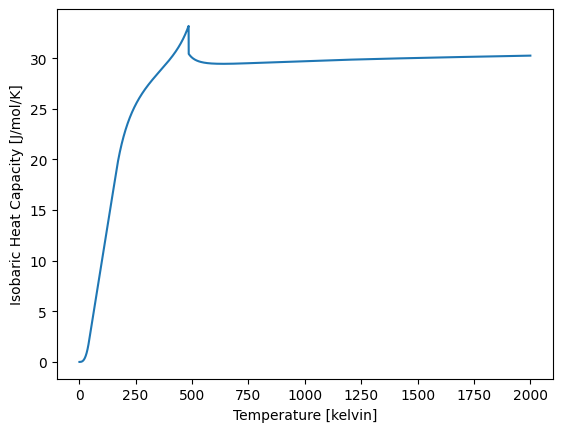

In [3]:
heat_capacity = as_property('HM.T')
heat_capacity.display_name = 'Isobaric Heat Capacity'
heat_capacity.display_units = 'J/mol/K'
plt.xlabel(f'{v.T.display_name} [{v.T.display_units}]')
plt.ylabel(f'{heat_capacity.display_name} [{heat_capacity.display_units}]')
plt.plot(wks.get(v.T), wks.get(heat_capacity))

# Equilibrium Properties and Partial Ordering (Al-Fe and Al-Ni)

In [4]:
from pycalphad import Database, Model, Workspace, as_property, variables as v
import matplotlib.pyplot as plt

## Al-Fe (Heat Capacity and Degree of Ordering)
Here we compute equilibrium thermodynamic properties in the Al-Fe system. We know that only B2 and liquid are stable in the temperature range of interest, but we just as easily could have included all the phases in the calculation using `my_phases = list(db.phases.keys())`. Notice that the syntax for specifying a range is `(min, max, step)`. We can also directly specify a list of temperatures using the list syntax, e.g., `[300, 400, 500, 1400]`.

In [5]:
dbf = Database('databases/alfe_sei.TDB')
components = ['AL', 'FE', 'VA']
my_phases = ['LIQUID', 'B2_BCC']
conditions = {v.X('AL'): 0.25, v.T: (300, 2000, 10), v.P: 101325, v.N: 1}
wks1 = Workspace(dbf, components , my_phases, conditions, calc_opts=dict(pdens=500))  # use higher point density for convergence near the ordering temperature


We also compute degree of ordering at fixed temperature as a function of composition.

In [6]:
conditions2 = {v.X('AL'): (0,1,0.01), v.T: 700, v.P: 101325, v.N: 1}
wks2 = Workspace(dbf, components, my_phases, conditions2)

### Plots
Next we plot the degree of ordering versus temperature. We can see that the decrease in the degree of ordering is relatively steady and continuous. This is indicative of a second-order transition from partially ordered B2 to disordered bcc (A2).

Text(0, 0.5, 'Degree of ordering')

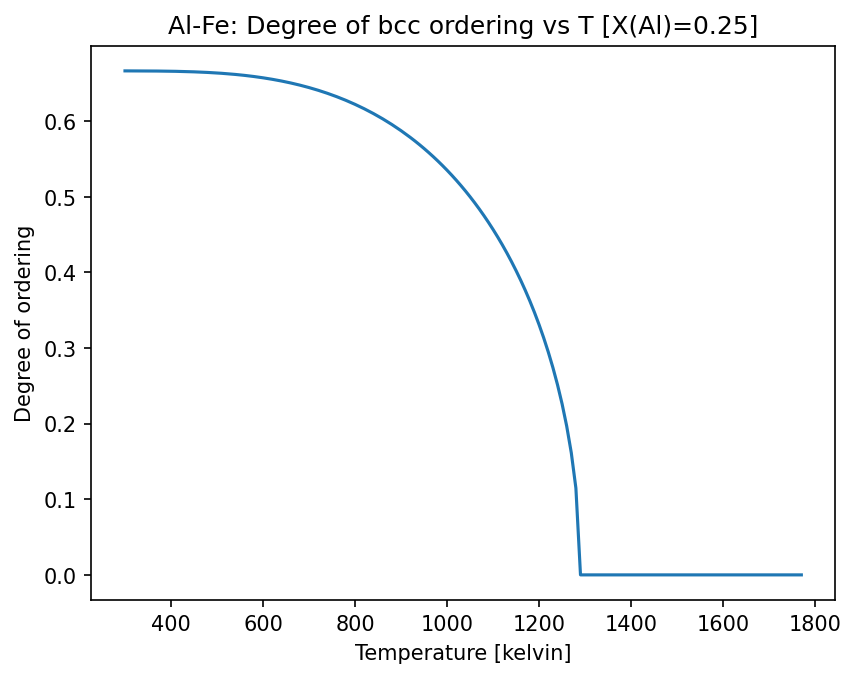

In [7]:
degree_of_ordering = as_property('degree_of_ordering(B2_BCC)')
degree_of_ordering.display_name = 'Degree of ordering'
fig, ax = plt.subplots(dpi=150)
ax.plot(wks1.get(v.T), wks1.get(degree_of_ordering))
ax.set_title('Al-Fe: Degree of bcc ordering vs T [X(Al)=0.25]')
ax.set_xlabel(f'{v.T.display_name} [{v.T.display_units}]')
ax.set_ylabel(f'{degree_of_ordering.display_name}')

For the heat capacity curve shown below we notice a sharp increase in the heat capacity around 730 K. This is indicative of a magnetic phase transition and, indeed, the temperature at the peak of the curve coincides with 75% of 1043 K, the Curie temperature of pure Fe. (Pure bcc Al is paramagnetic so it has an effective Curie temperature of 0 K.)

The decrease in heat capacity near 1280 K corresponds to the order-disorder transition observed in the above figure. We also observe a sharp jump in the heat capacity near 1800 K, corresponding to the melting of the bcc phase.

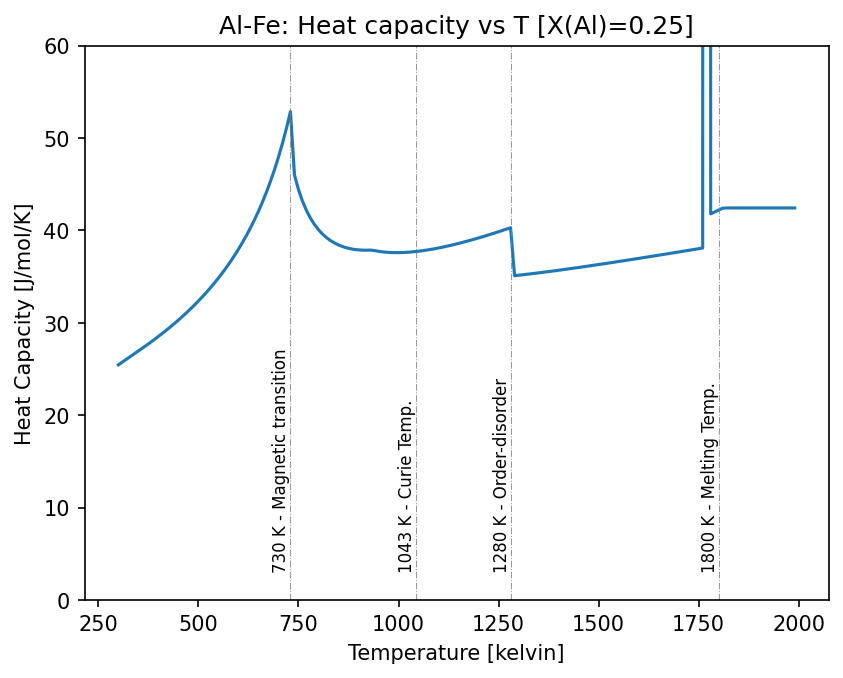

In [8]:
heat_capacity = as_property('HM.T')
heat_capacity.display_name = 'Heat Capacity'
heat_capacity.display_units = 'J/mol/K'
fig, ax = plt.subplots(dpi=150)
ax.plot(wks1.get(v.T), wks1.get(heat_capacity))
ax.set_title('Al-Fe: Heat capacity vs T [X(Al)=0.25]')
ax.set_xlabel(f'{v.T.display_name} [{v.T.display_units}]')
ax.set_ylabel(f'{heat_capacity.display_name} [{heat_capacity.display_units}]')
ax.set_ylim(0, 60)

critical_temperatures = [730, 1043, 1280, 1800]
special_labels = ['Magnetic transition', 'Curie Temp.', 'Order-disorder', 'Melting Temp.']
for idx, t in enumerate(critical_temperatures):
    ax.axvline(t, color='gray', linestyle='-.', linewidth=0.5, alpha=0.8)
    ax.text(t, 0.05, f"{t} K - {special_labels[idx]}", transform=ax.get_xaxis_transform(),
            rotation=90, va='bottom', ha='right', fontsize=8)

To understand more about what's happening around 700 K, we plot the degree of ordering versus composition. Note that this plot excludes all other phases except `B2_BCC`. We observe the presence of disordered bcc (A2) until around 13% Al or Fe, when the phase begins to order.

Text(0, 0.5, 'Degree of ordering')

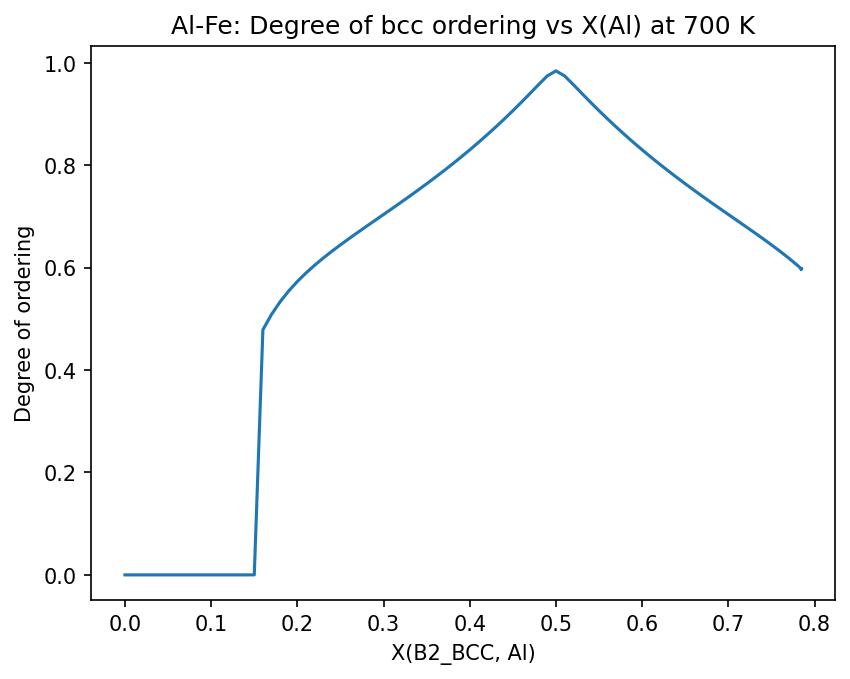

In [9]:
fig, ax = plt.subplots(dpi=150)
desired_phase = 'B2_BCC'
ax.plot(wks2.get(v.X(desired_phase, 'AL')), wks2.get(degree_of_ordering))
ax.set_title('Al-Fe: Degree of bcc ordering vs X(Al) at 700 K')
ax.set_xlabel(f"X(B2_BCC, Al)")
ax.set_ylabel(f'{degree_of_ordering.display_name}')

Notice that the plot abruptly ends around 0.8 fraction of Al, corresponding to the (metastable, because only liquid is entered) limit of stability of B2 on the phase diagram at this temperature. Because we want to plot in the metastable region, we will now tell `pycalphad` that we want to remove liquid from the calculation and then repeat it.

Text(0, 0.5, 'Degree of ordering')

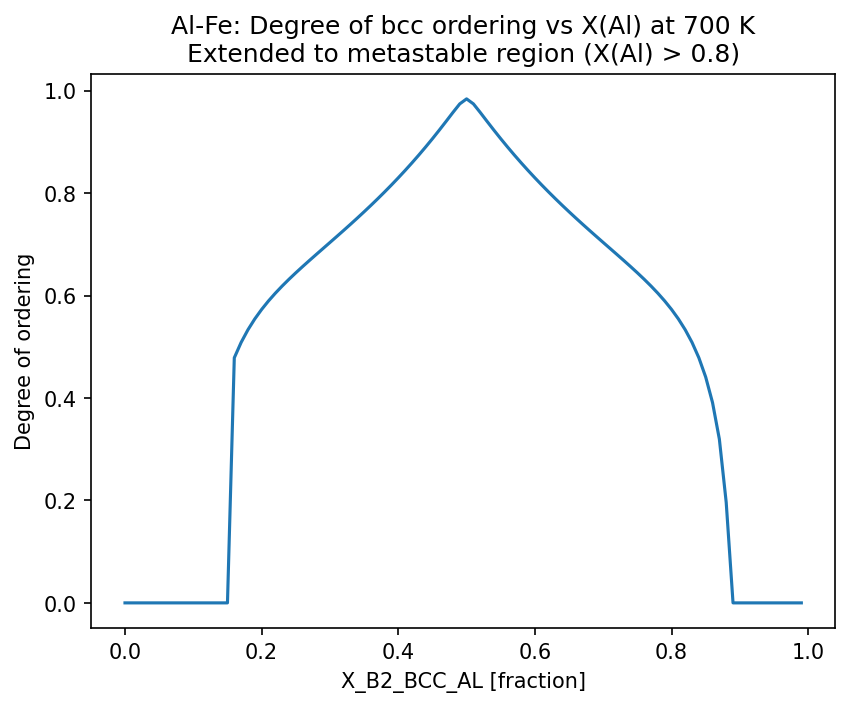

In [10]:
wks2.phases = [desired_phase]

fig, ax = plt.subplots(dpi=150)
ax.plot(wks2.get(v.X(desired_phase, 'AL')), wks2.get(degree_of_ordering))
ax.set_title('Al-Fe: Degree of bcc ordering vs X(Al) at 700 K\nExtended to metastable region (X(Al) > 0.8)')
ax.set_xlabel(f"{v.X(desired_phase, 'AL').display_name} [{v.X(desired_phase, 'AL').display_units}]")
ax.set_ylabel(f'{degree_of_ordering.display_name}')

### Site fractions across the ordering transition

A complementary view of the order/disorder transition is to look directly at the site fractions of each species on each sublattice. In the `B2_BCC` sublattice model (`(AL,FE)(AL,FE)(VA)`), the ordered state has Al preferentially occupying one substitutional sublattice and Fe the other; at the transition temperature, the site fractions on the two sublattices converge to the same overall value.

We restrict the calculation to `B2_BCC` only so the site fractions can be tracked into the metastable region without `LIQUID` interfering, and use a `Model` to enumerate the site-fraction symbols.

Text(0, 0.5, 'Site fraction')

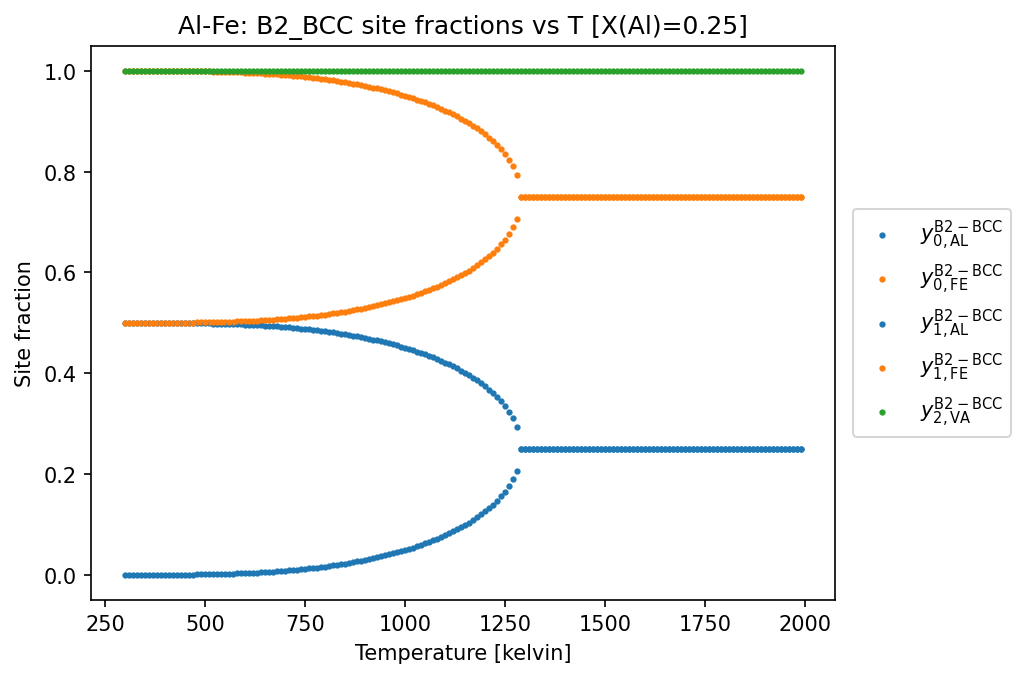

In [11]:
wks_sf = wks1.copy()
wks_sf.phases = ['B2_BCC']

mod = Model(dbf, components, 'B2_BCC')

fig, ax = plt.subplots(dpi=150)
# the sublattices for the B2 phase are equivalent by symmetry
# set up a color lookup dict to color lines by species
colors = dict(zip(sorted(set([sf.species for sf in mod.site_fractions])), plt.rcParams['axes.prop_cycle'].by_key()['color']))
for sf_sym in mod.site_fractions:
    ax.scatter(wks_sf.get(v.T), wks_sf.get(sf_sym), s=4, label=f'${sf_sym._latex()}$', c=colors[sf_sym.species])
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
ax.set_title('Al-Fe: B2_BCC site fractions vs T [X(Al)=0.25]')
ax.set_xlabel(f'{v.T.display_name} [{v.T.display_units}]')
ax.set_ylabel('Site fraction')

## Al-Ni (Degree of Ordering)

In [12]:
db_alni = Database('databases/NI_AL_DUPIN_2001.TDB')
components = ['AL', 'NI', 'VA']
phases = ['LIQUID', 'FCC_L12']
conditions = {v.X('AL'): 0.10, v.T: (300, 2500, 10), v.P: 101325}
wks3 = Workspace(db_alni, components, phases, conditions, calc_opts=dict(pdens=500))

### Plots
In the plot below we observe two phases designated `FCC_L12`. This is indicative of a miscibility gap. The ordered gamma-prime phase (`FCC#2`) steadily decreases in amount with increasing temperature until it completely disappears around `750 K`, leaving only the disordered gamma phase (`FCC#1`).

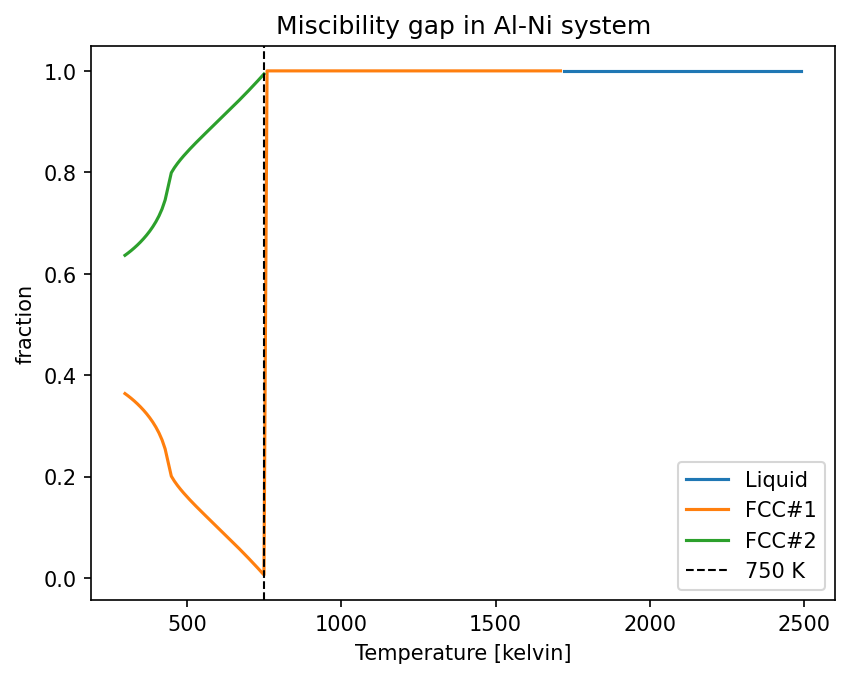

In [13]:
fig = plt.figure(dpi=150)
ax = fig.add_subplot()
ax.plot(wks3.get(v.T), wks3.get('NP(LIQUID)'), label='Liquid')
ax.plot(wks3.get(v.T), wks3.get('NP(FCC_L12#1)'), label='FCC#1')
ax.plot(wks3.get(v.T), wks3.get('NP(FCC_L12#2)'), label='FCC#2')
ax.axvline(750, color='k', linestyle='--', linewidth=1, label='750 K')
ax.set_title("Miscibility gap in Al-Ni system")
ax.set_xlabel(f'{v.T.display_name} [{v.T.display_units}]')
ax.set_ylabel('fraction')
ax.legend()

In the plot below we see that the degree of ordering does not change at all in each phase. There is a very abrupt disappearance of the completely ordered gamma-prime phase, leaving the completely disordered gamma phase. This is a first-order phase transition.

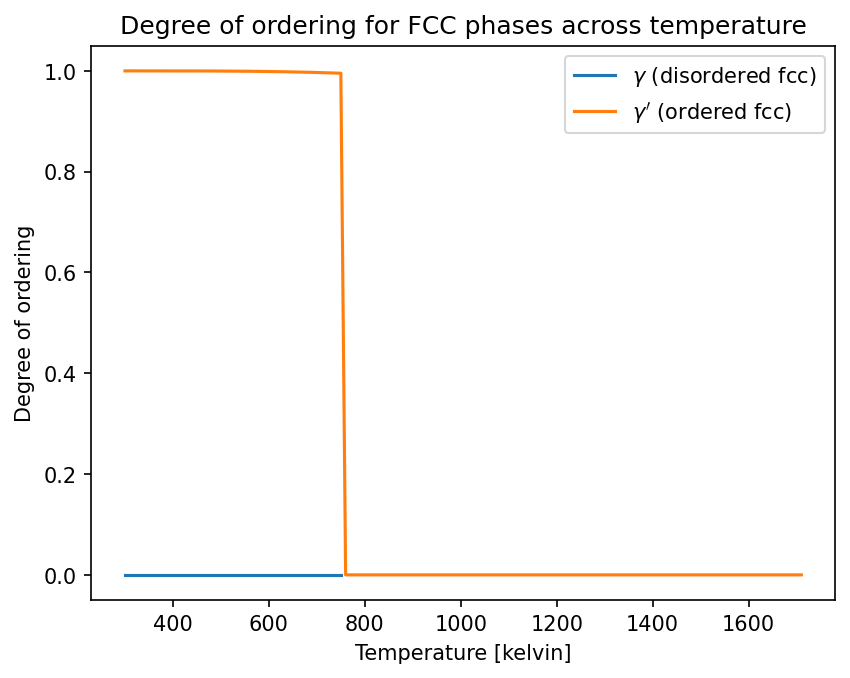

In [14]:
dis_degree_of_ordering = as_property('degree_of_ordering(FCC_L12#2)')
dis_degree_of_ordering.display_name = '$\\gamma$ (disordered fcc)'

L12_degree_of_ordering = as_property('degree_of_ordering(FCC_L12#1)')
L12_degree_of_ordering.display_name = '$\\gamma^\\prime$ (ordered fcc)'

fig = plt.figure(dpi=150)
ax = fig.add_subplot()
ax.plot(wks3.get(v.T), wks3.get(dis_degree_of_ordering),
        label=dis_degree_of_ordering.display_name)

ax.plot(wks3.get(v.T), wks3.get(L12_degree_of_ordering),
        label=L12_degree_of_ordering.display_name)

ax.set_title("Degree of ordering for FCC phases across temperature")
ax.set_ylabel("Degree of ordering")
ax.set_xlabel(f'{v.T.display_name} [{v.T.display_units}]')
ax.legend()

# Gibbs Energy of Each Phase at Fixed Composition

It can be useful to compare the Gibbs energies of individual phases at a fixed alloy composition across temperature, for example to understand which phase becomes stable when, or to inspect the relative metastability of competing phases.

This example shows how to compute $G_M(T)$ for each phase in the Al-Mg system at a fixed Mg mole fraction by constructing one `Workspace` per phase.

In [15]:
import matplotlib.pyplot as plt
from pycalphad import Database, Workspace, variables as v

Set up the database, components, and a temperature sweep at fixed composition `X(Mg) = 0.3`.

In [16]:
dbf = Database('databases/Al-Mg_Zhong.tdb')
components = ['AL', 'MG', 'VA']
mg_composition = 0.3  # mole fraction

conditions = {
    v.N: 1,
    v.P: 1e5,
    v.T: (300, 2000, 20),
    v.X('MG'): mg_composition,
}

Loop over the phases in the database. For each phase, build a `Workspace` restricted to that single phase so the equilibrium calculation cannot pick a different phase. Plot the Gibbs energy as a function of temperature.

Stoichiometric phases (e.g. `ALMG_BETA` and `ALMG_EPSILON`) only exist at their fixed composition, so they have no valid solution at `X(Mg) = 0.3` and are skipped automatically (their curves are all NaN).

Skipping ALMG_BETA: no valid solution at X(Mg)=0.3
Skipping ALMG_EPSILON: no valid solution at X(Mg)=0.3


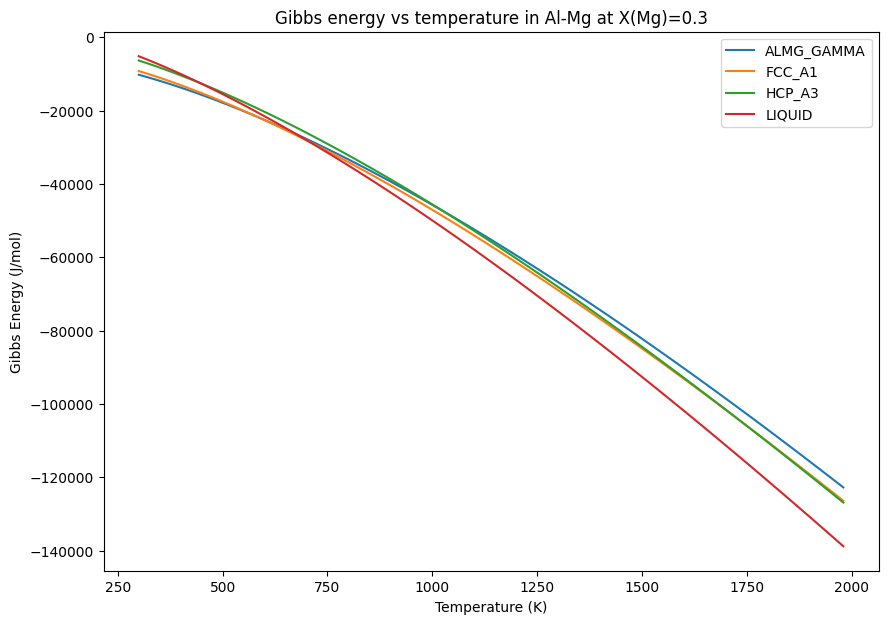

In [17]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
for phase_name in sorted(dbf.phases.keys()):
    wks = Workspace(dbf, components, [phase_name], conditions)
    T = wks.get(v.T)
    GM = wks.get('GM')
    if np.all(np.isnan(GM)):
        print(f'Skipping {phase_name}: no valid solution at X(Mg)={mg_composition}')
        continue
    ax.plot(T, GM, label=phase_name)

ax.set_title(f'Gibbs energy vs temperature in Al-Mg at X(Mg)={mg_composition}')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Gibbs Energy (J/mol)')
ax.legend(loc='best')

# Calculate and Plot Activity

Given an existing database for Al-Zn, we would like to calculate the activity of the liquid.

## Experimental activity results

In order to make sure we are correct, we'll compare the values with experimental results.
Experimental activities are digitized from Fig. 18 in [A. Yazawa, Y.K. Lee, Thermodynamic Studies of the Liquid Aluminum Alloy Systems, Trans. Japan Inst. Met. 11 (1970) 411–418](https://doi.org/10.2320/matertrans1960.11.411).

The measurements at at 1073 K and they used a reference state of the pure Zn at that temperature.


In [18]:
exp_x_zn =   [0.0482, 0.1990, 0.3550, 0.5045, 0.6549, 0.8070, 0.9569]
exp_acr_zn = [0.1154, 0.3765, 0.5411, 0.6433, 0.7352, 0.8384, 0.9531]

## Set up the database

Al-Zn database is taken from [S. Mey, Reevaluation of the Al-Zn system, Zeitschrift Für Met. 84(7) (1993) 451–455](https://doi.org/10.1515/ijmr-1993-840704).

In [19]:
from pycalphad import Database, equilibrium, variables as v
import numpy as np

dbf = Database('databases/alzn_mey.tdb')

comps = ['AL', 'ZN', 'VA']
phases = list(dbf.phases.keys())

## Calculate the reference state

Because all chemical activities must be specified with a reference state, we're going to choose a reference state as the pure element at the same temperature, consistent with the experimental data.

In [20]:
components = ['ZN']
temperature = 1073
conditions = {v.N: 1, v.P: 101325, v.T: temperature}
ref_eq = equilibrium(dbf, components, phases, conditions)

## Calculate the equilibria

Do the calculation over the composition range

In [21]:
conditions2 = {v.N: 1, v.P: 1013325, v.T: temperature, v.X('ZN'): (0, 1, 0.005)}
eq = equilibrium(dbf, comps, phases, conditions2)

## Get the chemical potentials and calculate activity

We need to select the chemical potentials from the xarray Dataset and calculate the activity.

In [22]:
chempot_ref = ref_eq.MU.sel(component='ZN').squeeze()
chempot = eq.MU.sel(component='ZN').squeeze()

R = float(v.R)
acr_zn = np.exp((chempot - chempot_ref)/(R*temperature))

## Plot the result

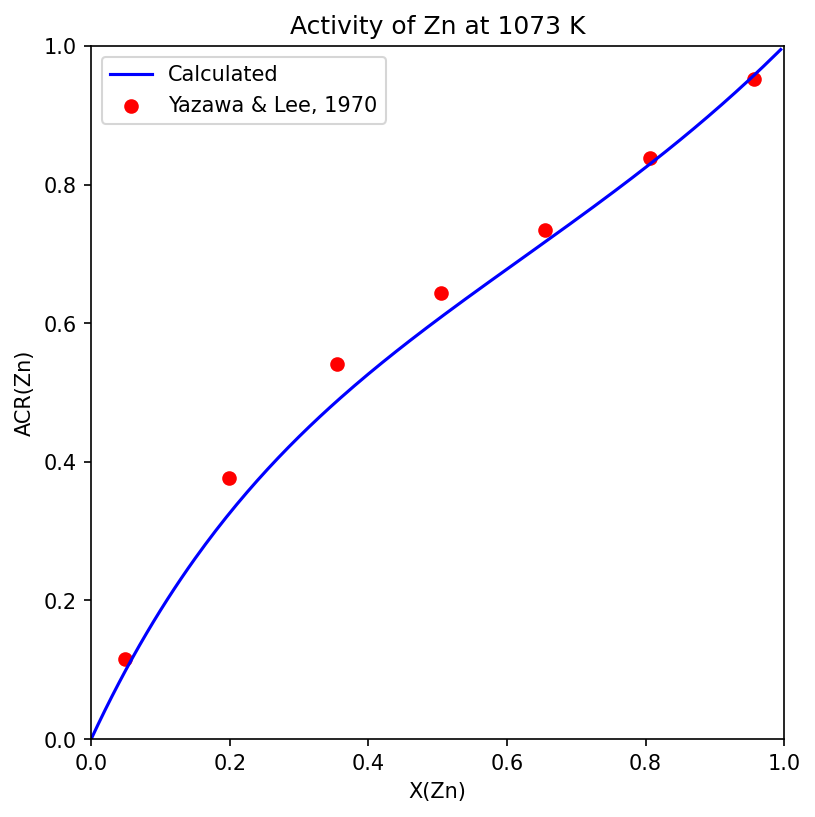

In [23]:
import matplotlib.pyplot as plt

plt.plot(eq.X.sel(component='ZN', vertex=0).squeeze(), acr_zn, label='Calculated', color='blue')

# add experimental data
plt.scatter(exp_x_zn, exp_acr_zn, label='Yazawa & Lee, 1970', color='red')

plt.xlim((0, 1))
plt.ylim((0, 1))
plt.gca().set_aspect(1)
plt.gcf().set_size_inches(9, 6)
plt.gcf().set_dpi(150)
plt.xlabel('X(Zn)')
plt.ylabel('ACR(Zn)')
plt.title(f'Activity of Zn at {temperature} K')
plt.legend(loc=0)

# Phase Fractions and Phase Compositions vs Temperature

A common CALPHAD workflow is to take a single alloy composition and look at how the equilibrium phase fractions and compositions evolve with temperature.

This example uses [the open-source MatCalc Fe-Cr-Ni database](https://www.matcalc.at/index.php/databases/open-databases) to compute, for an Fe-18Cr-8Ni stainless steel composition (mass fractions):

1. The molar phase fractions `NP(<phase>)` as a function of temperature.
2. The mole-fraction composition of the sigma phase `X(SIGMA, <element>)` as a function of temperature.

It also shows how to convert between mass and mole fractions using `pycalphad.variables.get_mole_fractions`.


In [24]:
import warnings
import matplotlib.pyplot as plt
import numpy as np

from pycalphad import Database, Workspace, variables as v

# This database emits a benign warning at load about extra type-definition
# characters; it has no effect on results.
warnings.filterwarnings('ignore', category=UserWarning, module='pycalphad.io.tdb')

Load the database and translate the mass-fraction conditions `W(CR) = 0.18, W(NI) = 0.08` (with Fe as the dependent component) into the mole-fraction conditions that the Workspace expects.

In [25]:
dbf = Database('databases/mc_fe_v2.059.pycalphad.tdb')
components = ['NI', 'CR', 'FE', 'VA']

# GP_MAT is a model phase that should not appear in an equilibrium calculation
phases = sorted(set(dbf.phases.keys()) - {'GP_MAT'})

mass_fracs = {v.W('CR'): 0.18, v.W('NI'): 0.08}
conditions = v.get_mole_fractions(mass_fracs, 'FE', dbf)
conditions[v.T] = (700, 1300, 10)
conditions[v.P] = 1e5
conditions[v.N] = 1

wks = Workspace(dbf, components, phases, conditions)
conditions

{X_CR: 0.19152036799248282,
 X_NI: 0.07541162078822543,
 T: (700, 1300, 10),
 P: 100000.0,
 N: 1}

## Phase fractions vs temperature

Use `wks.get_dict("NP(*)")` to retrieve molar fractions for every phase. Filter out phases that never reach a meaningful fraction so only the stable phases are plotted.

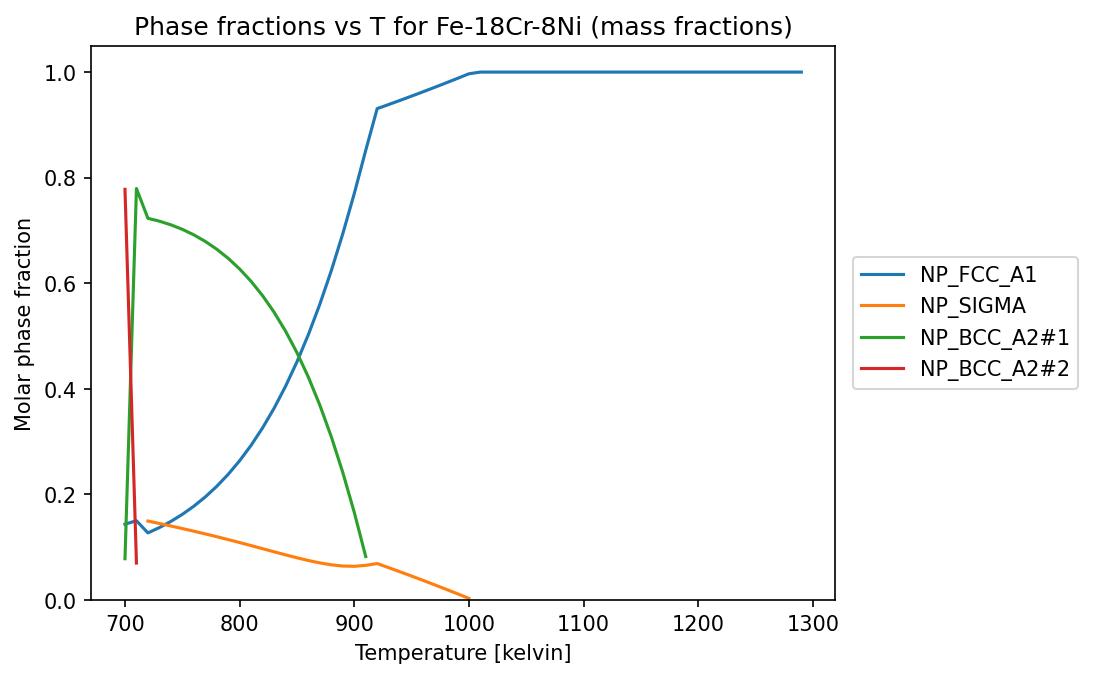

In [26]:
T = wks.get(v.T)
np_dict = wks.get_dict('NP(*)')

fig, ax = plt.subplots(dpi=150)
for prop, values in np_dict.items():
    arr = np.asarray(values)
    if not np.any(np.isfinite(arr) & (arr > 1e-6)):
        continue
    ax.plot(T, arr, label=str(prop))

ax.set_title('Phase fractions vs T for Fe-18Cr-8Ni (mass fractions)')
ax.set_xlabel(f'{v.T.display_name} [{v.T.display_units}]')
ax.set_ylabel('Molar phase fraction')
ax.set_ylim(0, 1.05)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))

## SIGMA phase composition vs temperature

For a single phase, `wks.get(v.X(phase, element))` returns the per-phase mole fraction of each element across the temperature sweep. Values are `NaN` where the phase is not stable.

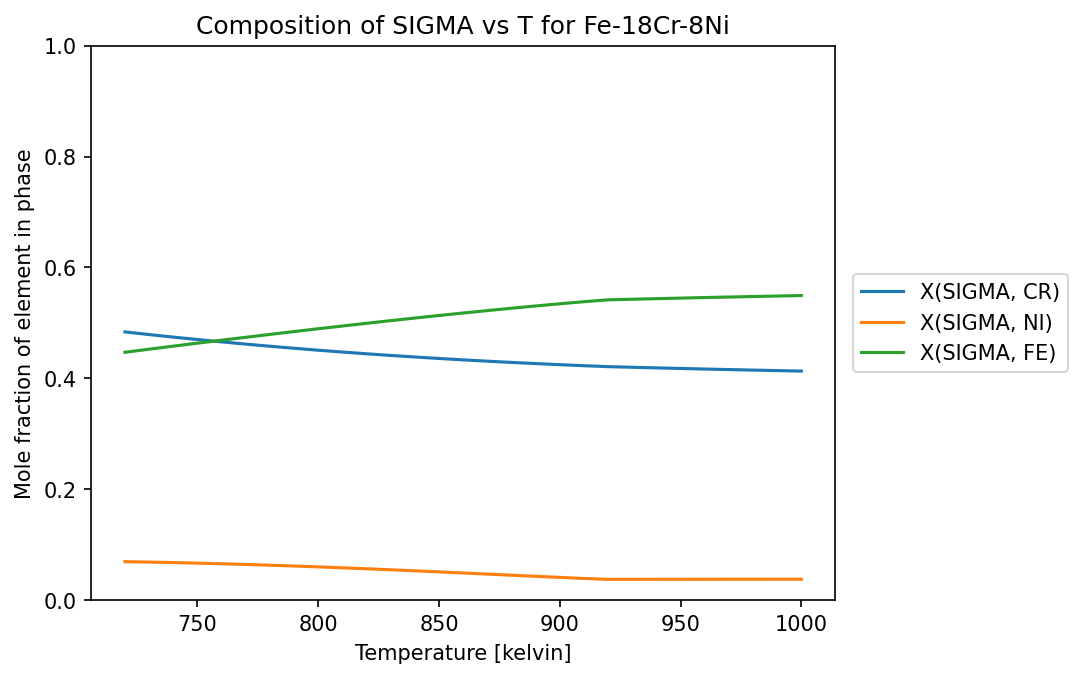

In [27]:
desired_phase = 'SIGMA'
elements = ['CR', 'NI', 'FE']

fig, ax = plt.subplots(dpi=150)
for el in elements:
    ax.plot(T, wks.get(v.X(desired_phase, el)), label=f"X({desired_phase}, {el})")

ax.set_title(f'Composition of {desired_phase} vs T for Fe-18Cr-8Ni')
ax.set_xlabel(f'{v.T.display_name} [{v.T.display_units}]')
ax.set_ylabel('Mole fraction of element in phase')
ax.set_ylim(0, 1.0)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))

# Calculations with Reference States

## Experimental Reference States: Formation and Mixing Energy

By default, energies calculated with pycalphad (e.g. `GM`, `HM`, etc.) are the absolute energies as defined in the database and are not calculated with respect to any reference state.

pycalphad allows the reference for any property to be set to arbitrary phases and temperature/pressure conditions through the `ReferenceState` meta-property, which creates new properties for the specified property that are referenced to the specified reference state.

### Enthalpy of mixing

The enthalpy of mixing in the liquid, analogous to what would be measured experimentally, is calculated and plotted below with the reference states of the pure elements both set to the liquid phase. No temperature and pressure are specified as we would like the reference state to be calculated with respect to the calculation temperature.

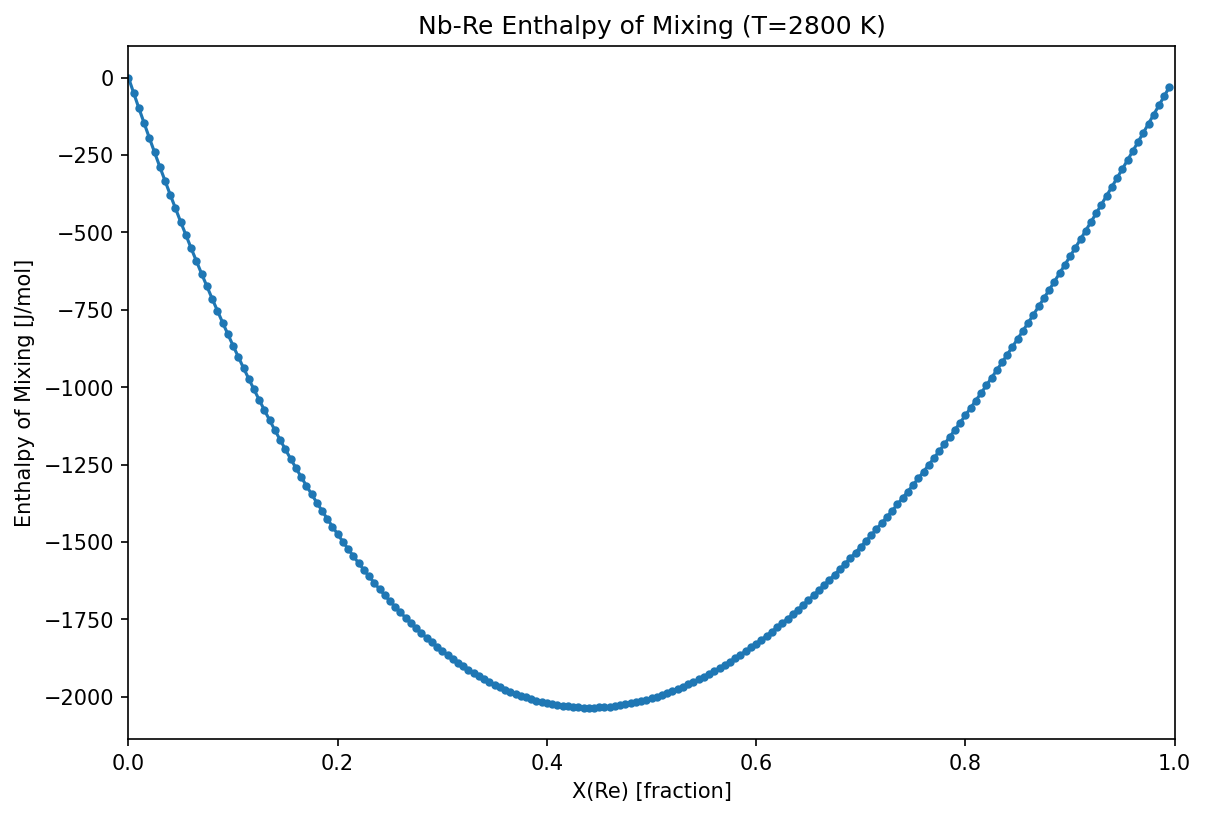

In [28]:
from pycalphad import Workspace, variables as v
from pycalphad.property_framework import ReferenceState
import matplotlib.pyplot as plt

db_name = "databases/nbre_liu.tdb"
components = ["NB", "RE", "VA"]
liq_phase = "LIQUID_RENB"
phases = [liq_phase]
conditions = {v.P: 101325, v.T: 2800, v.X("RE"): (0, 1, 0.005)}
wks1 = Workspace(db_name, components, phases, conditions)

ref1 = ReferenceState([(liq_phase, {v.X("RE"): 0}),
                      (liq_phase, {v.X("RE"): 1})
                     ], wks1)

ref_enthalpy = ref1('HM')
ref_enthalpy.display_name = 'Enthalpy of Mixing'

x_re_1, enthalpy_of_mixing = wks1.get(v.X('RE'), ref1('HM'))

fig = plt.figure(figsize=(9,6), dpi=150)
ax = fig.gca()
ax.plot(x_re_1, enthalpy_of_mixing, marker='.', label=ref_enthalpy.display_name)
ax.set_xlim((0, 1))
ax.set_xlabel(f'X(Re) [{v.X("RE").implementation_units}]')
ax.set_ylabel("Enthalpy of Mixing [J/mol]")
ax.set_title('Nb-Re Enthalpy of Mixing (T=2800 K)')
plt.show()

### Enthalpy of formation - convex hull

Formation enthalpies are often reported in the literature with respect to the pure elements in their stable phase at 298.15 K. The enthalpy of formation of the phases in equilibrium, analogous to what would be measured experimentally, is calculated and plotted below for 2800 K, with the reference states of the pure elements both set to the stable phases and fixed at 298.15 K and 1 atm.

/var/folders/hb/yhrcbqxx4kx8ywp_8nvb50pm0000gn/T/ipykernel_18440/1769966587.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


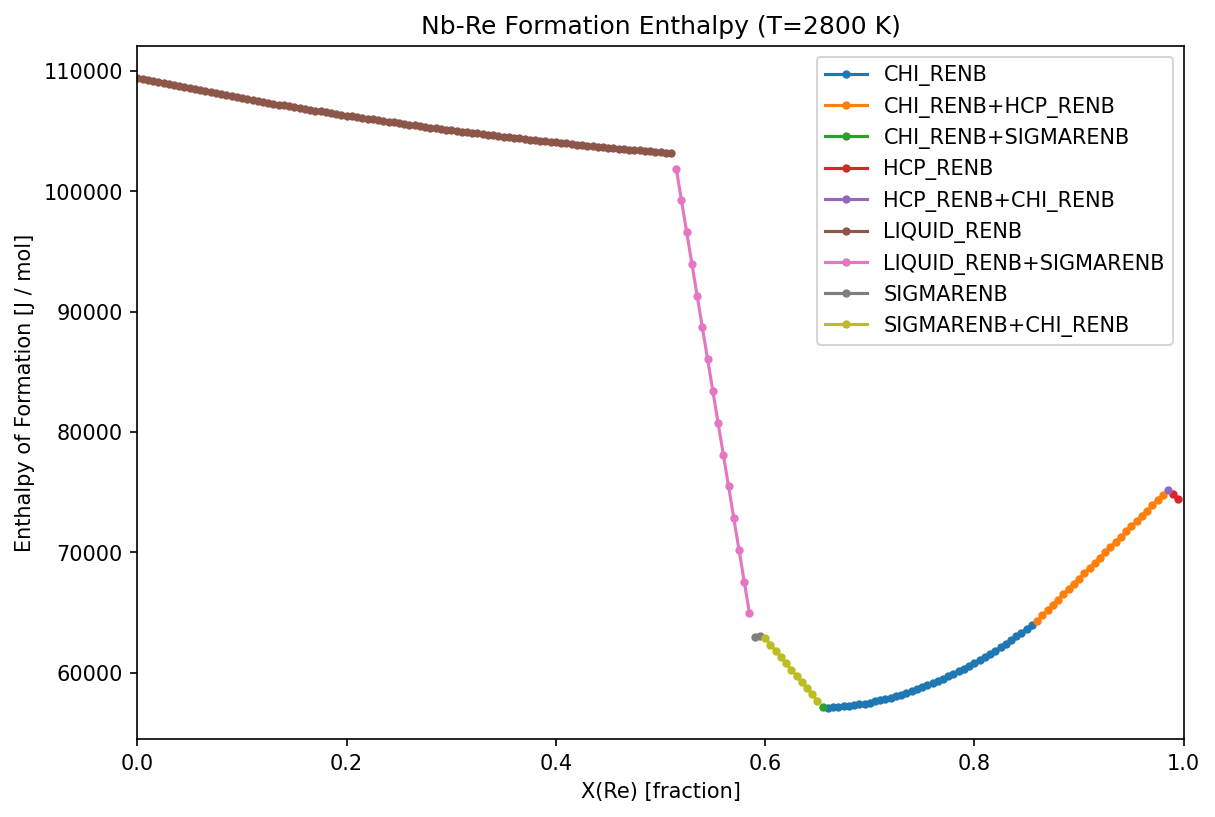

In [29]:
from pycalphad import Database, as_property
import numpy as np

dbf_nbre = Database(db_name)
phases2 = sorted(dbf_nbre.phases.keys())
wks2 = Workspace(dbf_nbre, components, phases2, conditions)

ref2 = ReferenceState([("BCC_RENB", {v.X("RE"): 0, v.T: 298.15}), # Nb
                       ("HCP_RENB", {v.X("RE"): 1, v.T: 298.15})  # Re
                     ], wks2)

x_re, enthalpy_of_formation = wks2.get(v.X('RE'), ref2('HM'))

# Find the groups of stable phases in equilibrium e.g. [CHI_RENB] and [CHI_RENB, HCP_RENB]
unique_phase_sets = np.unique(wks2.eq.Phase.squeeze(), axis=0)

# Plot
fig, ax = plt.subplots(figsize=(9,6), dpi=150)

for phase_set in unique_phase_sets:
    label = '+'.join([ph for ph in phase_set if ph != ''])
    # composition indices with the same stable set of phases
    unique_phase_idx = np.nonzero(np.all(wks2.eq.Phase.squeeze() == phase_set, axis=1))[0]
    ax.plot(x_re[unique_phase_idx], enthalpy_of_formation[unique_phase_idx], marker='.', label=label)

ax.set_xlim((0, 1))
ax.set_xlabel(f'X(Re) [{v.X("RE").implementation_units}]')
ax.set_ylabel(f'Enthalpy of Formation [{as_property("HM").implementation_units}]')
ax.set_title('Nb-Re Formation Enthalpy (T=2800 K)')
ax.legend()
fig.show()

# Plot energy curves for several phases

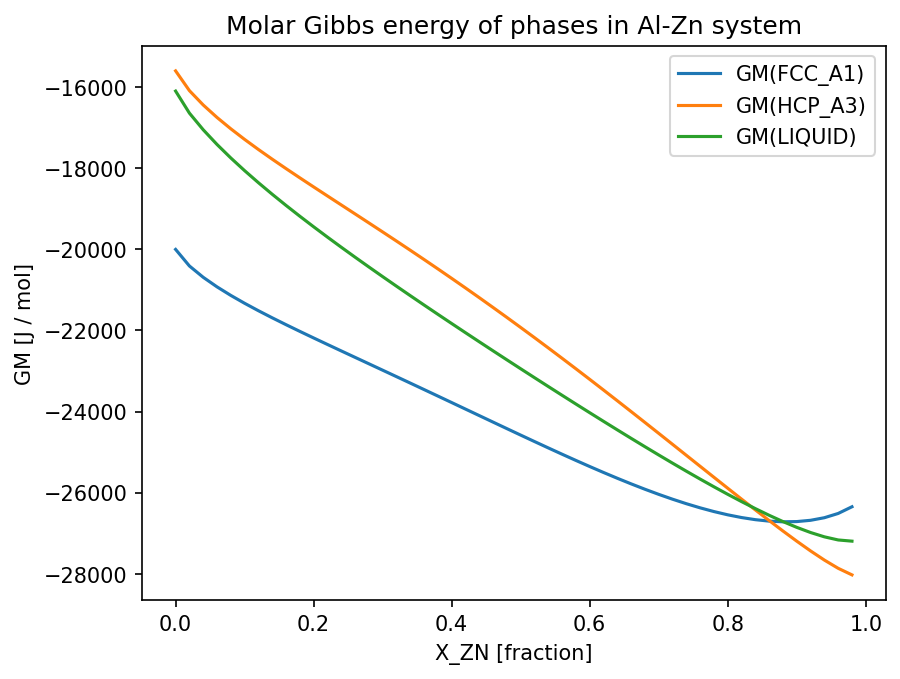

In [30]:
from pycalphad import Workspace, variables as v
from pycalphad.property_framework.metaproperties import IsolatedPhase
import matplotlib.pyplot as plt

db = 'databases/alzn_mey.tdb'
components = ['AL', 'ZN']
phases = ['FCC_A1', 'HCP_A3', 'LIQUID']
conditions = {v.X('ZN'):(0,1,0.02), v.T: (300, 1000, 10), v.P:101325, v.N: 1}

conditions2 = {v.X('ZN'):(0,1,0.02), v.T: 600, v.P:101325, v.N: 1}
wks2 = Workspace(db, components, phases, conditions2)

fig = plt.figure(dpi=150)
ax = fig.add_subplot()

x = wks2.get(v.X('ZN'))

for phase_name in wks2.phases:
    # Workaround for poor starting point selection in IsolatedPhase
    metastable_wks = wks2.copy()
    metastable_wks.phases = [phase_name]
    prop = IsolatedPhase(phase_name, metastable_wks)(f'GM({phase_name})')
    prop.display_name = f'GM({phase_name})'
    ax.plot(x, wks2.get(prop), label=prop.display_name)

ax.set_title("Molar Gibbs energy of phases in Al-Zn system")
ax.set_xlabel(f"{v.X('ZN').display_name} [{v.X('ZN').display_units}]")
ax.set_ylabel(f"GM [{prop.display_units}]")
ax.legend()

# Calculating Energy Surfaces

It is very common in CALPHAD modeling to directly examine the Gibbs energy surface of all the constituent phases in a system.

Below we show how the Gibbs energy of all phases may be calculated as a function of composition at a given temperature (2800 K).

Note that the $\chi$ phase has additional, internal degrees of freedom which allow it to take on multiple states for a given
overall composition. Only the low-energy states are relevant to calculating the equilibrium phase diagram.

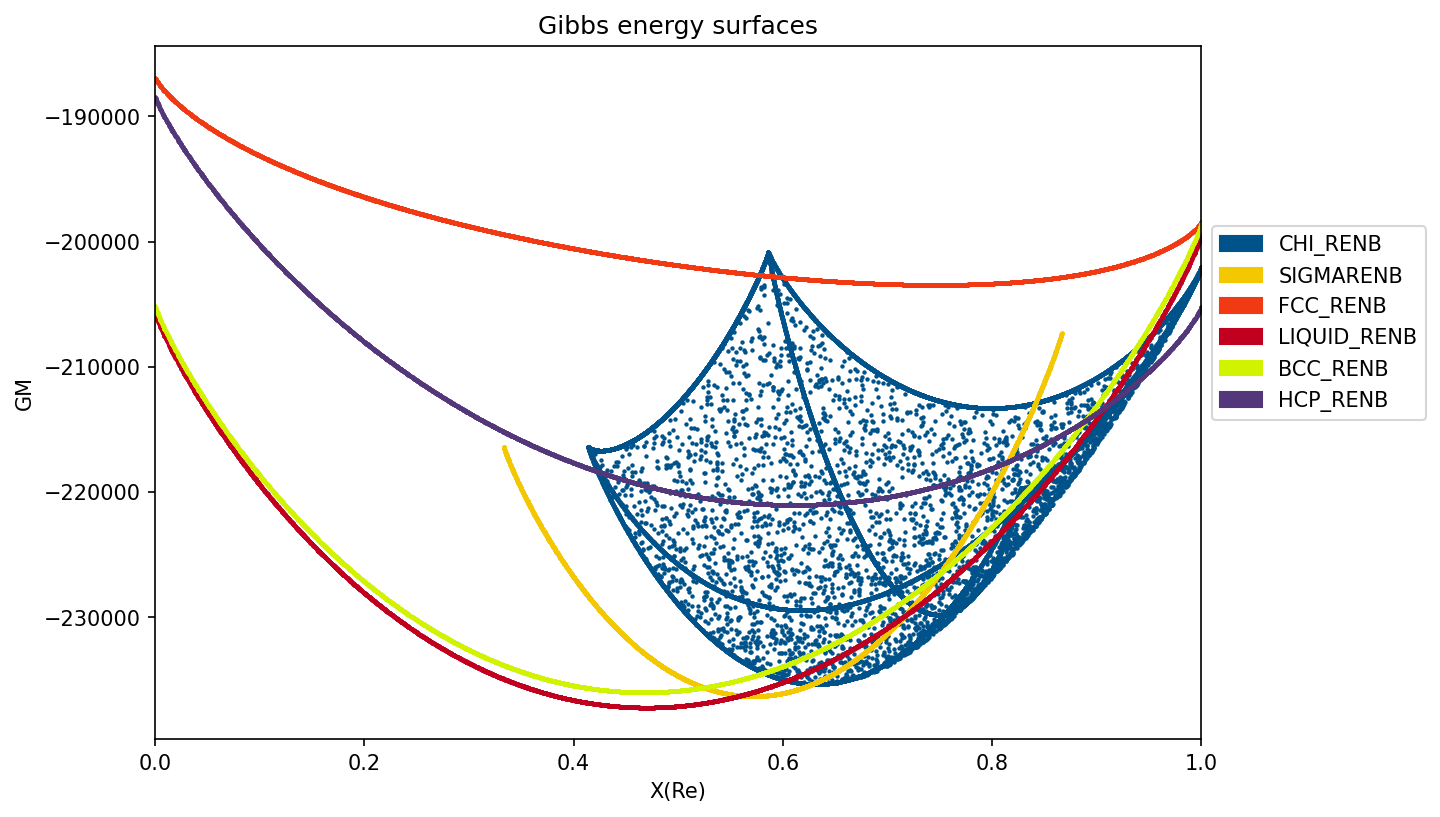

In [31]:
import matplotlib.pyplot as plt
from pycalphad import Database, calculate
from pycalphad.plot.utils import phase_legend

# Load database and choose the phases that will be plotted
db_nbre = Database('databases/nbre_liu.tdb')
components = ['NB', 'RE']
my_phases_nbre = ['CHI_RENB', 'SIGMARENB', 'FCC_RENB', 'LIQUID_RENB', 'BCC_RENB', 'HCP_RENB']

# Get the colors that map phase names to colors in the legend
legend_handles, color_dict = phase_legend(my_phases_nbre)

fig = plt.figure(figsize=(9,6), dpi=150)
ax = fig.gca()

# Loop over phases, calculate the Gibbs energy, and scatter plot GM vs. X(RE)
for phase_name in my_phases_nbre:
    result = calculate(db_nbre, components, phase_name, N=1, P=101325, T=2800, output='GM')
    ax.scatter(result.X.sel(component='RE'), result.GM, marker='.', s=5, color=color_dict[phase_name])

# Format the plot
ax.set_xlabel('X(Re)')
ax.set_ylabel('GM')
ax.set_xlim(0, 1)
ax.set_title("Gibbs energy surfaces")
ax.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1, 0.6))
plt.show()

## Molar Ratios and Linear Combination Conditions

In [32]:
from pycalphad import Workspace

db_al_cu_y = Database('databases/Al-Cu-Y.tdb')
comps = ['AL', 'CU', 'Y', 'VA']
phases = list(db_al_cu_y.phases.keys())
conds = {v.T: 830, v.P:101325,
         v.X('AL')/v.X('CU'): 5, # molar ratio condition
         0.1 * v.X('Y') + v.X('AL'): 0.6} # linear combination of mole fractions condition
wks = Workspace(db_al_cu_y, comps, phases, conds)
print(wks.get('X(AL)', 'X(CU)', 'X(Y)'))

[array(0.56818182), array(0.11363636), array(0.31818182)]
